In [167]:
import pandas as pd
import requests
print("set up working")

set up working


In [168]:
price_url = "https://api.energy-charts.info/price"

price_params = {
    "country": "de",
    "start": "2026-01-01",
    "end": "2026-09-13"
}

price_response = requests.get(price_url, params=price_params)



In [222]:
print(price_response.status_code)

price_data = price_response.json()

print(price_data.keys())


200
dict_keys(['license_info', 'unix_seconds', 'price', 'unit', 'deprecated'])


In [223]:
print(len(price_data["unix_seconds"]))

print(
    pd.to_datetime(price_data["unix_seconds"][0], unit="s"),
    pd.to_datetime(price_data["unix_seconds"][-1], unit="s")
)

24572
2025-12-31 23:00:00 2026-09-13 21:45:00


In [215]:
price_df_timestamp = pd.to_datetime(
    price_data["unix_seconds"], unit="s", utc=True
).tz_convert("Europe/Berlin")

In [216]:
price_df = pd.DataFrame({
    "timestamp": price_df_timestamp ,
    "price": price_data["price"]
})

In [212]:
print(price_df.head())
print(price_df.shape)

                  timestamp  price
0 2026-01-01 00:00:00+01:00  63.64
1 2026-01-01 00:15:00+01:00  61.48
2 2026-01-01 00:30:00+01:00  58.00
3 2026-01-01 00:45:00+01:00  49.99
4 2026-01-01 01:00:00+01:00  60.01
(24572, 2)


In [219]:
local_diff = price_df["timestamp"].dt.tz_localize(None).diff()
print(local_diff.value_counts())

timestamp
0 days 00:15:00    24570
0 days 01:15:00        1
Name: count, dtype: int64


#### Data-quality note: daylight-saving time

The dataset uses Europe/Berlin local time. During the daylight-saving transition, four expected 15-minute local timestamps do not occur. This produces one 1-hour-15-minute gap in the naive local-time sequence.

This is a calendar/time-zone effect, not ordinary missing data, so the observations were not imputed or removed.

In [221]:
url = "https://api.energy-charts.info/v2/public_power"

params = {
    "country": "de",
    "start": "2026-01-01",
    "end": "2026-09-13"
}

power_response = requests.get(url, params=params)
power_data = power_response.json()

print(power_response.status_code)
print(power_data.keys())

200
dict_keys(['schema_version', 'endpoint', 'country', 'bidding_zone', 'timezone', 'resolution', 'interval_minutes', 'unit', 'generated_at', 'available_from', 'available_until', 'series', 'data', 'attributes', 'license', 'deprecated'])


In [224]:

print(power_data["series"])
print(power_data["data"][0])

[{'id': 'hydro_pumped_storage_consumption', 'name': 'Hydro pumped storage consumption'}, {'id': 'cross_border_electricity_trading', 'name': 'Cross border electricity trading'}, {'id': 'hydro_run_of_river', 'name': 'Hydro Run-of-River'}, {'id': 'biomass', 'name': 'Biomass'}, {'id': 'fossil_brown_coal_lignite', 'name': 'Fossil brown coal / lignite'}, {'id': 'fossil_hard_coal', 'name': 'Fossil hard coal'}, {'id': 'fossil_oil', 'name': 'Fossil oil'}, {'id': 'fossil_coal_derived_gas', 'name': 'Fossil coal-derived gas'}, {'id': 'fossil_gas', 'name': 'Fossil gas'}, {'id': 'geothermal', 'name': 'Geothermal'}, {'id': 'hydro_water_reservoir', 'name': 'Hydro water reservoir'}, {'id': 'hydro_pumped_storage', 'name': 'Hydro pumped storage'}, {'id': 'others', 'name': 'Others'}, {'id': 'waste', 'name': 'Waste'}, {'id': 'wind_offshore', 'name': 'Wind offshore'}, {'id': 'wind_onshore', 'name': 'Wind onshore'}, {'id': 'solar', 'name': 'Solar'}, {'id': 'load', 'name': 'Load'}, {'id': 'residual_load', 'na

In [225]:
rows = []

for row in power_data["data"]:
    rows.append({
        "timestamp": row["timestamp"],
        "load": row["values"].get("load"),
        "wind_onshore": row["values"].get("wind_onshore"),
        "solar": row["values"].get("solar")
    })

power_df = pd.DataFrame(rows)

In [226]:
power_df["timestamp"] = pd.to_datetime(
    power_df["timestamp"],
    utc=True
).dt.tz_convert("Europe/Berlin")

In [230]:
print(power_df["timestamp"].min(), power_df["timestamp"].max())
print(price_df["timestamp"].min(), price_df["timestamp"].max())

2026-01-01 00:00:00+01:00 2026-09-13 23:45:00+02:00
2026-01-01 00:00:00+01:00 2026-09-13 23:45:00+02:00


In [228]:
print(power_df.head())
print(power_df.shape)

                  timestamp     load  wind_onshore  solar
0 2026-01-01 00:00:00+01:00  46427.4       31462.6    0.0
1 2026-01-01 00:15:00+01:00  46085.1       31849.2    0.0
2 2026-01-01 00:30:00+01:00  46038.6       32711.4    0.0
3 2026-01-01 00:45:00+01:00  45940.4       33195.1    0.0
4 2026-01-01 01:00:00+01:00  45656.0       33481.0    0.0
(24572, 4)


In [229]:
print(power_df["timestamp"].equals(price_df["timestamp"]))

True


In [231]:
print(power_df["timestamp"].dtype)
print(price_df["timestamp"].dtype)

datetime64[ns, Europe/Berlin]
datetime64[ns, Europe/Berlin]


In [233]:
merged_df = power_df.merge(price_df, on="timestamp", how="inner")

print(merged_df.head())
print(merged_df.shape)

                  timestamp     load  wind_onshore  solar  price
0 2026-01-01 00:00:00+01:00  46427.4       31462.6    0.0  63.64
1 2026-01-01 00:15:00+01:00  46085.1       31849.2    0.0  61.48
2 2026-01-01 00:30:00+01:00  46038.6       32711.4    0.0  58.00
3 2026-01-01 00:45:00+01:00  45940.4       33195.1    0.0  49.99
4 2026-01-01 01:00:00+01:00  45656.0       33481.0    0.0  60.01
(24572, 5)


In [234]:
print(merged_df.isna().sum())

timestamp       0
load            0
wind_onshore    0
solar           0
price           0
dtype: int64


In [235]:
print(merged_df["timestamp"].duplicated().sum())

0


In [236]:
print(merged_df.dtypes)

timestamp       datetime64[ns, Europe/Berlin]
load                                  float64
wind_onshore                          float64
solar                                 float64
price                                 float64
dtype: object


In [192]:
merged_df.describe()

,load,wind_onshore,solar,price
count,24572.000000,24572.000000,24572.000000,24572.000000
mean,52965.013100,11837.663898,11621.827218,104.995103
std,9175.188844,8739.478472,15842.653384,64.545605
min,32445.500000,63.900000,0.000000,-499.990000
25%,45494.425000,4911.750000,0.000000,80.527500
50%,53036.050000,9871.300000,1313.400000,110.685000
75%,58826.775000,16854.750000,22058.100000,140.815000
max,78372.600000,47300.000000,58507.000000,747.100000


In [193]:
merged_df[merged_df["price"] < 0]

,timestamp,load,wind_onshore,solar,price
43,2026-01-01 10:45:00+01:00,48872.1,40445.4,6869.4,-0.01
47,2026-01-01 11:45:00+01:00,51014.8,40804.2,8551.9,-0.01
48,2026-01-01 12:00:00+01:00,51261.9,40313.6,8699.7,-0.01
49,2026-01-01 12:15:00+01:00,51439.7,40573.1,8763.7,-0.01
50,2026-01-01 12:30:00+01:00,51539.7,40663.0,8670.7,-0.01
...,...,...,...,...,...
24436,2026-09-12 14:00:00+02:00,46825.5,4731.7,36058.5,-0.48
24437,2026-09-12 14:15:00+02:00,46686.6,4680.9,35191.8,-0.19
24438,2026-09-12 14:30:00+02:00,46259.0,4371.6,34097.9,-0.13
24439,2026-09-12 14:45:00+02:00,46378.9,4243.0,33283.5,-0.17


In [237]:
print((merged_df["price"] < 0).sum())

1784


## EDA


In [196]:
merged_df[["load", "wind_onshore", "solar", "price"]].describe()

,load,wind_onshore,solar,price
count,24572.000000,24572.000000,24572.000000,24572.000000
mean,52965.013100,11837.663898,11621.827218,104.995103
std,9175.188844,8739.478472,15842.653384,64.545605
min,32445.500000,63.900000,0.000000,-499.990000
25%,45494.425000,4911.750000,0.000000,80.527500
50%,53036.050000,9871.300000,1313.400000,110.685000
75%,58826.775000,16854.750000,22058.100000,140.815000
max,78372.600000,47300.000000,58507.000000,747.100000


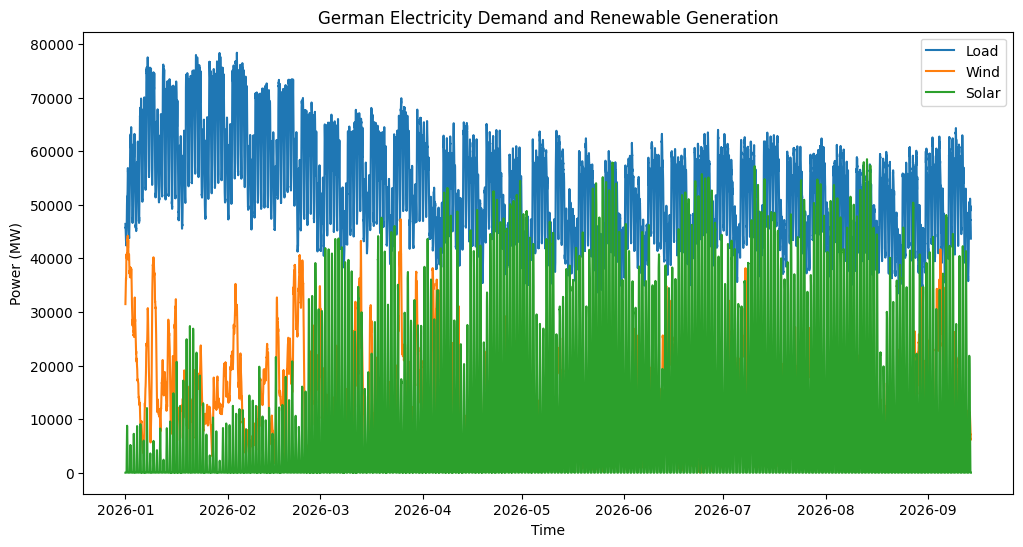

In [197]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(merged_df["timestamp"], merged_df["load"], label="Load")
plt.plot(merged_df["timestamp"], merged_df["wind_onshore"], label="Wind")
plt.plot(merged_df["timestamp"], merged_df["solar"], label="Solar")
plt.xlabel("Time")
plt.ylabel("Power (MW)")
plt.title("German Electricity Demand and Renewable Generation")
plt.legend()
plt.show()

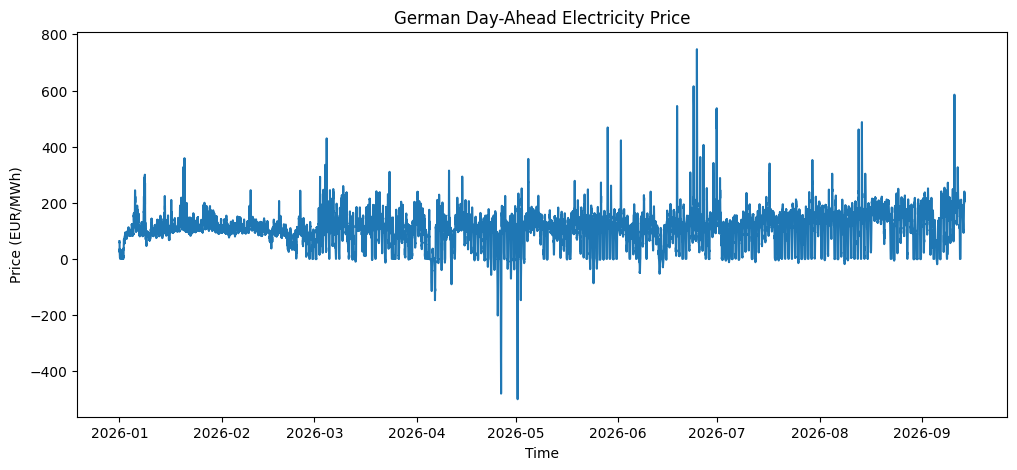

In [198]:
plt.figure(figsize=(12, 5))
plt.plot(merged_df["timestamp"], merged_df["price"])
plt.xlabel("Time")
plt.ylabel("Price (EUR/MWh)")
plt.title("German Day-Ahead Electricity Price")
plt.show()

In [199]:
merged_df[["load", "wind_onshore", "solar", "price"]].corr()

,load,wind_onshore,solar,price
load,1.000000,0.141104,0.103194,0.108622
wind_onshore,0.141104,1.000000,-0.294680,-0.229890
solar,0.103194,-0.294680,1.000000,-0.585817
price,0.108622,-0.229890,-0.585817,1.000000


In [200]:
load_median = merged_df["load"].median()
merged_df["demand_level"] = merged_df["load"].apply(
    lambda x: "High" if x >= load_median else "Low"
)
print(load_median)
print(merged_df["demand_level"].value_counts())

53036.05
demand_level
Low     12286
High    12286
Name: count, dtype: int64


In [201]:
print(
    merged_df[merged_df["demand_level"] == "High"][["solar", "price"]].corr()
)

print(
    merged_df[merged_df["demand_level"] == "Low"][["solar", "price"]].corr()
)

          solar     price
solar  1.000000 -0.547041
price -0.547041  1.000000
          solar     price
solar  1.000000 -0.702367
price -0.702367  1.000000


In [202]:
print(
    merged_df[merged_df["demand_level"] == "High"][["load", "price"]].corr()
)

print(
    merged_df[merged_df["demand_level"] == "Low"][["load", "price"]].corr()
)

           load     price
load   1.000000  0.099779
price  0.099779  1.000000
           load     price
load   1.000000  0.010453
price  0.010453  1.000000


In [203]:
merged_df["hour"]=merged_df["timestamp"].dt.hour
hourly=merged_df.groupby("hour")[["load", "wind_onshore", "solar", "price"]].mean()

print(hourly)

              load  wind_onshore         solar       price
hour                                                      
0     45999.254492  13416.650391      0.000000  119.339287
1     44437.279395  13243.028613      0.000000  113.433271
2     43586.534510  12984.524706      0.000000  109.846363
3     43580.237305  12699.869531      0.000000  108.058457
4     44392.415820  12526.826758      5.969043  108.763457
5     46679.521387  12559.221484    152.503223  113.936250
6     51452.331738  12726.746191   1464.083398  126.266182
7     55208.446484  12028.542383   5705.318359  130.628926
8     57845.514453  10940.799316  13152.699219  120.214775
9     58676.305859  10118.473633  21383.347461   97.076934
10    58749.533887   9807.453711  28077.587305   74.188945
11    58595.510449   9768.916895  32353.204883   56.573594
12    57731.707031   9721.111133  34180.391992   43.589990
13    56562.454102   9783.396680  33776.503613   35.814277
14    55221.605371  10094.336816  31534.647168   39.6454

## Feature-engineering

In [204]:
merged_df["hour"] = merged_df["timestamp"].dt.hour
merged_df["day_of_week"] = merged_df["timestamp"].dt.dayofweek
merged_df["month"] = merged_df["timestamp"].dt.month

In [205]:
print(merged_df[["timestamp", "hour", "day_of_week", "month"]].head())

                  timestamp  hour  day_of_week  month
0 2026-01-01 00:00:00+01:00     0            3      1
1 2026-01-01 00:15:00+01:00     0            3      1
2 2026-01-01 00:30:00+01:00     0            3      1
3 2026-01-01 00:45:00+01:00     0            3      1
4 2026-01-01 01:00:00+01:00     1            3      1


In [206]:
merged_df["renewable_generation"] = (
    merged_df["wind_onshore"] + merged_df["solar"]
)

In [207]:
merged_df[["renewable_generation", "load", "price"]].corr()

,renewable_generation,load,price
renewable_generation,1.000000,0.182946,-0.720165
load,0.182946,1.000000,0.108622
price,-0.720165,0.108622,1.000000


In [208]:
merged_df[["wind_onshore", "solar", "price"]].corr()

,wind_onshore,solar,price
wind_onshore,1.00000,-0.294680,-0.229890
solar,-0.29468,1.000000,-0.585817
price,-0.22989,-0.585817,1.000000
